# Linear and Logistic Regression: The Foundations of Deep Learning
---

## Linear Regression

### What is Linear Regression?

Linear regression is a statistical method used to model and analyze the relationships between a dependent (target) variable and one or more independent (predictor) variables. The primary goal is to establish a linear equation that can predict the value of the dependent variable based on the values of the independent variables. The simplest form is simple linear regression, which involves one independent variable, while multiple linear regression involves two or more independent variables.

In machine learning, linear regression is a fundamental supervised learning algorithm used for regression tasks, where the output is a continuous value. It assumes a linear relationship between the input features and the target variable. The model learns this relationship by fitting a line (or hyperplane in higher dimensions) that minimizes the difference between the actual and predicted values.

![](https://miro.medium.com/v2/resize:fit:1400/0*0plB5_YzkViGnD3j.gif)

### The Linear Regression Equation

Linear regression is a foundational supervised learning algorithm used to model the relationship between a continuous dependent variable $y$ and one or more independent variables (features) $X$. At its simplest, with a single feature, it seeks to find a straight line that best fits the observed data points.

The equation for the regression line is:

$$
\hat{y} = \theta_0 + \theta_1 X
$$

- $X$: the input feature (independent variable).  
- $\hat{y}$: the predicted output (dependent variable).  
- $\theta_0$: the **intercept**, representing the value of $\hat{y}$ when $X = 0$.  
- $\theta_1$: the **slope**, indicating how much $\hat{y}$ changes for a one-unit change in $X$.  

Together, $(\theta_0, \theta_1)$ are the **parameters** the model must learn from the training data.

### The Cost Function

To measure how well a particular choice of parameters fits the data, we define a **cost function** that quantifies the aggregate error across all training examples. 

A common choice is the Mean Squared Error (MSE):

$$
J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} \bigl(\hat{y}_i - y_i\bigr)^2
$$

- $m$: total number of training examples.  
- $\hat{y}_i = \theta_0 + \theta_1 X_i$: model’s prediction for example $i$.  
- $y_i$: true target value for example $i$.  
- The factor $\tfrac{1}{2m}$ simplifies the derivative expressions (the “2” cancels when taking gradients).

By minimizing $J(\theta)$, we find the parameters that yield the smallest average squared difference between predictions and actual values.

### Linear Regression Assumptions

1. **Linear Relationship:** The core premise of multiple linear regression is the existence of a linear relationship between the dependent (outcome) variable and the independent variables. This linearity can be visually inspected using scatterplots, which should reveal a straight-line relationship rather than a curvilinear one.

2. **Multivariate Normality:** The analysis assumes that the residuals (the differences between observed and predicted values) are normally distributed. This assumption can be assessed by examining histograms or Q-Q plots of the residuals, or through statistical tests such as the Kolmogorov-Smirnov test.

3. **No Multicollinearity:** It is essential that the independent variables are not too highly correlated with each other, a condition known as multicollinearity. This can be checked using:
    - Correlation matrices, where correlation coefficients should ideally be below 0.80.
    - Variance Inflation Factor (VIF), with VIF values above 10 indicating problematic multicollinearity. 

4. **Homoscedasticity:** The variance of error terms (residuals) should be consistent across all levels of the independent variables. A scatterplot of residuals versus predicted values should not display any discernible pattern, such as a cone-shaped distribution, which would indicate heteroscedasticity. 

## Linear Regression: Modern Approach vs. From Scratch

#### Generating Data For The Examples

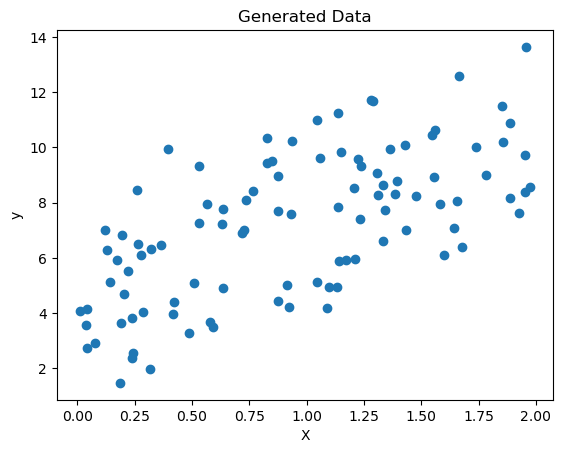

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Set number of data points
num_points = 100

# Generate some data
np.random.seed(0)
X = 2 * np.random.rand(num_points, 1)
y = 4 + 3 * X + 2 * np.random.randn(num_points, 1)

# Plot the data
plt.scatter(X, y)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Generated Data')
plt.show()

### Modern Approach To Linear Regression Using Sci-Kit Learn

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, mean_squared_log_error,
    r2_score, explained_variance_score, max_error, median_absolute_error
)

#### Initialize Parameters

In [4]:
# Initialize and train the model
model = LinearRegression()
model.fit(X, y)

# Get model parameters
theta_0 = model.intercept_[0]  # Intercept
theta_1 = model.coef_[0][0]   # Slope

print(f"Intercept (theta_0): {theta_0}")
print(f"Slope (theta_1): {theta_1}")

Intercept (theta_0): 4.444302154894459
Slope (theta_1): 2.936935021402039


#### Use Prediction Function

In [5]:
y_pred = model.predict(X)

#### Compute Loss

In [6]:
# Calculate Mean Squared Error
mse = mean_squared_error(y, y_pred)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 3.9697545948985926


#### Plot Results

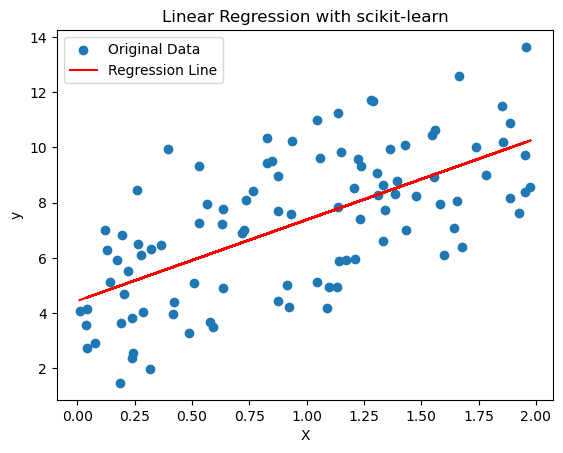

In [7]:
plt.scatter(X, y, label='Original Data')
plt.plot(X, y_pred, color='red', label='Regression Line')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression with scikit-learn')
plt.legend()
plt.show()

#### Show Model Metrics

In [8]:
metrics = {
    "Mean Absolute Error (MAE)": mean_absolute_error(y, y_pred),
    "Mean Squared Error (MSE)": mean_squared_error(y, y_pred),
    "Root Mean Squared Error (RMSE)": mean_squared_error(y, y_pred, squared=False),
    "Mean Squared Logarithmic Error (MSLE)": mean_squared_log_error(y, np.clip(y_pred, 1e-10, None)),  # Clip to avoid log(0)
    "R² Score": r2_score(y, y_pred),
    "Explained Variance Score": explained_variance_score(y, y_pred),
    "Max Error": max_error(y, y_pred),
    "Median Absolute Error": median_absolute_error(y, y_pred),
}

for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

Mean Absolute Error (MAE): 1.6985
Mean Squared Error (MSE): 3.9698
Root Mean Squared Error (RMSE): 1.9924
Mean Squared Logarithmic Error (MSLE): 0.0765
R² Score: 0.4194
Explained Variance Score: 0.4194
Max Error: 4.3468
Median Absolute Error: 1.6093


### Linear Regression From Scratch

#### Initialize Parameters

In [9]:
theta = np.random.randn(2, 1)  # Random initial weights (theta)
learning_rate = 0.1

# Add x0 = 1 to each instance for the intercept term to make sure the by-hand process works correctly. 
X_b = np.c_[np.ones((num_points, 1)), X]#### Initialize Parameters

#### Create Prediction Function 
In this step, we are implementing a simple prediction function.

$
\hat{y} = X \cdot \theta
$
 
Here, $ X $ includes a column of ones for the intercept ($ \theta_0 $). So, there is an initialized starting point. 



In [10]:
def predict(X, theta):
    """
    Predicts y values based on current theta values.
    """
    return X.dot(theta)

#### Create The Compute Loss Function

 $
 J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} \left( \hat{y}_i - y_i \right)^2
 $

Where:
 - $ m $ is the number of training examples.
 - $ \hat{y}_i $ is the predicted value for the $ i^{th} $ example.
 - $ y_i $ is the actual value for the $ i^{th} $ example.

In [11]:
def compute_loss(y, y_pred):
    """
    Computes Mean Squared Error (MSE) Loss.
    """
    m = len(y)
    return np.sum((y - y_pred) ** 2) / (2 * m)

#### Computing The Gradient

$
\frac{\partial J(\theta)}{\partial \theta_j} = -\frac{1}{m} \sum_{i=1}^{m} (y_i - \hat{y}_i) x_{ij}
$

Where:
- $ J(\theta) $ is the cost function.
- $ m $ is the number of training examples.
- $ y_i $ is the actual value for the $ i^{th} $ example.
- $ \hat{y}_i $ is the predicted value for the $ i^{th} $ example.
- $ x_{ij} $ is the value of the $ j^{th} $ feature for the $ i^{th} $ training example.

The gradient measures how much $ J(\theta) $ changes with respect to $ \theta_j $. It is used to adjust $ \theta_j $ during gradient descent to minimize the cost function.

In [12]:
def compute_gradient(X, y, y_pred):
    """
    Computes the gradient of the loss function.
    """
    m = len(y)
    return -(1 / m) * X.T.dot(y - y_pred)

#### Training The Model Using Gradient Descent

This process uses the **update rule** to update the model parameters: 

$
\theta := \theta - \alpha \cdot \frac{\partial J(\theta)}{\partial \theta}
$

Where:
- $ \alpha $ is the learning rate.
- $ \frac{\partial J(\theta)}{\partial \theta} $ is the gradient of the cost function with respect to $ \theta $.

This process stops when the change in the loss is below a tolerance ($ \text{tol} $) or after a fixed number of iterations.

In [13]:
def gradient_descent(X, y, theta, learning_rate, num_iterations, tol=1e-6):
    """
    Performs gradient descent to minimize the loss function.
    """
    loss_history = []

    for i in range(num_iterations):
        # Compute predictions
        y_pred = predict(X, theta)

        # Compute the loss
        loss = compute_loss(y, y_pred)
        loss_history.append(loss)

        # Compute the gradient
        gradients = compute_gradient(X, y, y_pred)

        # Update theta using parameter update rule
        theta = theta - learning_rate * gradients

        # Check for convergence
        if i > 0 and abs(loss_history[-2] - loss_history[-1]) < tol:
            break

    return theta, loss_history

# Train the model
num_iterations = 1000
theta, loss_history = gradient_descent(X_b, y, theta, learning_rate, num_iterations)

#### Plotting The Loss

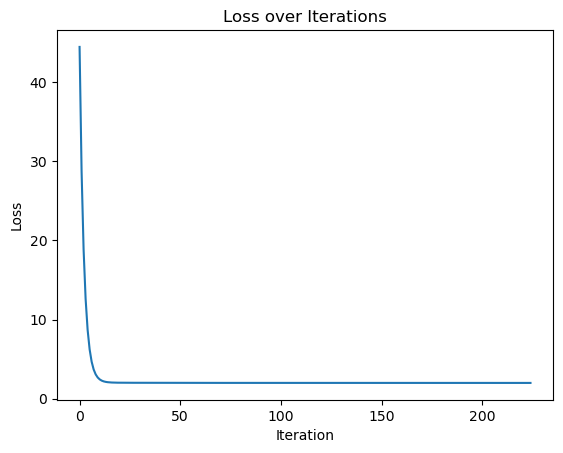

In [14]:
# Plot the loss over iterations
plt.plot(loss_history)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss over Iterations')
plt.show()

#### Making Predictions

In [15]:
# Make predictions
y_pred = predict(X_b, theta)

# Calculate Mean Squared Error
mse = mean_squared_error(y, y_pred)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 3.9698119948362076


#### Plotting The Regression Line

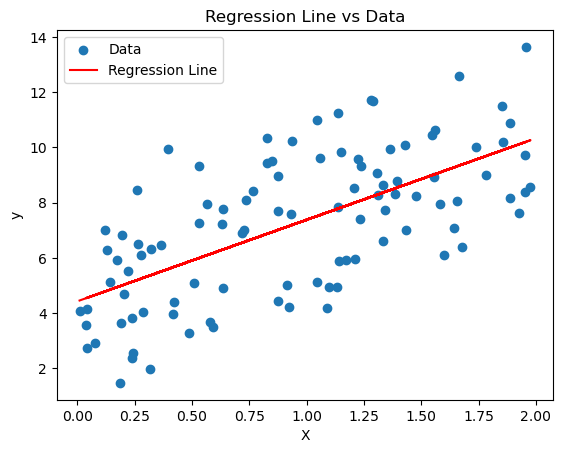

In [16]:
# Plot the regression line
plt.scatter(X, y, label='Data')
plt.plot(X, y_pred, color='red', label='Regression Line')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Regression Line vs Data')
plt.legend()
plt.show()

#### Showing The Model Metrics

In [17]:
metrics = {
    "Mean Absolute Error (MAE)": mean_absolute_error(y, y_pred),
    "Mean Squared Error (MSE)": mean_squared_error(y, y_pred),
    "Root Mean Squared Error (RMSE)": mean_squared_error(y, y_pred, squared=False),
    "Mean Squared Logarithmic Error (MSLE)": mean_squared_log_error(y, np.clip(y_pred, 1e-10, None)),  # Clip to avoid log(0)
    "R² Score": r2_score(y, y_pred),
    "Explained Variance Score": explained_variance_score(y, y_pred),
    "Max Error": max_error(y, y_pred),
    "Median Absolute Error": median_absolute_error(y, y_pred),
}

for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

Mean Absolute Error (MAE): 1.6987
Mean Squared Error (MSE): 3.9698
Root Mean Squared Error (RMSE): 1.9924
Mean Squared Logarithmic Error (MSLE): 0.0764
R² Score: 0.4194
Explained Variance Score: 0.4194
Max Error: 4.3560
Median Absolute Error: 1.6021


## Logistic Regression

### What is Logistic Regression?

Logistic regression is one of the simplest and most commonly used methods for binary classification. Despite its name, it is not a regression algorithm but rather a classification technique. It predicts the probability that an instance belongs to a specific class and uses this probability to make a classification decision.

Logistic regression models the relationship between the input features and the probability of the target class using the logistic (or sigmoid) function. This function maps any real-valued number to a range between 0 and 1, making it ideal for modeling probabilities. The decision boundary in logistic regression is linear, making it effective for problems where the classes are linearly separable.

In a binary classification scenario, the predicted probability is compared to a threshold (commonly 0.5) to determine the class label. For example, if the predicted probability of a sample belonging to the positive class is greater than or equal to 0.5, it is classified as positive; otherwise, it is classified as negative.

Logistic regression is particularly valuable because it is interpretable, computationally efficient, and serves as a foundation for understanding more advanced classification algorithms.

![](https://miro.medium.com/v2/resize:fit:1400/0*VkKvoiB4zD-P7yKa.gif)

### The Logistic Regression Equation

At its core, logistic regression uses the **logistic (sigmoid) function** to map any real‑valued input into the $0$–$1$ interval, which we interpret as a probability of the “positive” class.

$$
\hat{p} \;=\; \sigma(z) \;=\; \frac{1}{\,1 + e^{-z}\,},
\qquad
\text{where} \quad
z \;=\; \theta_0 + \theta_1x_1 + \theta_2x_2 + \dots + \theta_nx_n.
$$

* **$\hat{p}$** – predicted probability that the output $y = 1$  
* **$\sigma(\cdot)$** – sigmoid function  
* **$z$** – linear combination of the input features  
* **$\theta_0, \dots, \theta_n$** – parameters (weights + bias) learned from data  
* **$x_1, \dots, x_n$** – input feature values  


#### Log‑Odds (Link Function)

Logistic regression is a **linear model** in the log‑odds (logit) scale:

$$
\log\!\Bigg(\frac{\hat{p}}{1 - \hat{p}}\Bigg) \;=\; z \;=\; \boldsymbol{\theta}^\top \mathbf{x}.
$$

This equation shows that the log‑odds of the positive class are modeled as a linear function of the features, which is why we still call it a **regression**, even though the output after the sigmoid becomes a probability.


#### Why the Sigmoid?

* Keeps outputs between $0$ and $1$, making them valid probabilities.  
* Provides smooth, differentiable transitions, enabling gradient‑based optimization.  
* Converts a linear score $z$ into a nonlinear probability curve, allowing logistic regression to solve binary classification problems.

### The Cost Function

Because logistic regression predicts **probabilities**, squared error is no longer an appropriate loss function.
Predictions must be evaluated based on how well the model assigns probability mass to the correct outcome.

For this reason, logistic regression uses **log loss**, also known as **binary cross-entropy**:

$$
J(w, b) = -\frac{1}{n} \sum_{i=1}^{n}
\left[
y_i \log(\hat{y}_i) + (1 - y_i)\log(1 - \hat{y}_i)
\right]
$$

Where:
- $n$ is the number of training examples
- $y_i \in \{0, 1\}$ is the true label for the $i$-th observation
- $\hat{y}_i$ is the predicted probability that $y_i = 1$
- $w$ represents the model weights
- $b$ is the bias term

This loss function measures how well the predicted probabilities align with the observed outcomes.

Log loss behaves intuitively for probabilistic predictions:

- If $y_i = 1$ and $\hat{y}_i$ is close to 1, the loss is small
- If $y_i = 1$ and $\hat{y}_i$ is close to 0, the loss becomes very large
- If $y_i = 0$, the behavior is reversed

Because the logarithm grows rapidly for values close to 0, log loss **strongly penalizes confident but incorrect predictions**.

This encourages the model to produce well-calibrated probability estimates rather than extreme guesses.

## Logistic Regression: Modern Approach vs. From Scratch

#### Generating Samples

In [18]:
# Import necessary libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import random

# Load the Iris dataset
iris = load_iris()

# Filter to only classes 0 and 1
binary_data = [
    (x, label)
    for x, label in zip(iris.data, iris.target)
    if label != 2
]

# Oversample (with replacement) to 100 binary samples
X_binary, y_binary = zip(*random.choices(binary_data, k=100))

# Convert back to NumPy arrays
X_binary = np.array(X_binary)
y_binary = np.array(y_binary)

print(X_binary.shape, y_binary.shape)  # (100, 4) (100,)

(100, 4) (100,)


In [19]:
X_binary[0:5]

array([[6.3, 2.3, 4.4, 1.3],
       [5.6, 2.7, 4.2, 1.3],
       [5.1, 2.5, 3. , 1.1],
       [6.2, 2.2, 4.5, 1.5],
       [5.3, 3.7, 1.5, 0.2]])

In [20]:
y_binary[0:5]

array([1, 1, 1, 1, 0])

### Modern Approach To Logistic Regression Using Sci-Kit Learn

#### Creating Train Test Split

In [21]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_binary, y_binary, test_size=0.2, random_state=42)

#### Building The Model

In [22]:
# Create and train the logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

#### Evaluating The Model

In [23]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00         9

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



#### Examining Predictions

In [24]:
# Predict probabilities for the first few test samples
probabilities = model.predict_proba(X_test[:5])
print("\nPredicted Probabilities for the first 5 test samples:")
print(probabilities)

# Display the predicted classes for the first few test samples
predicted_classes = model.predict(X_test[:5])
print("\nPredicted Classes for the first 5 test samples:")
print(predicted_classes)


Predicted Probabilities for the first 5 test samples:
[[4.53559691e-03 9.95464403e-01]
 [9.74313379e-01 2.56866210e-02]
 [9.49366489e-04 9.99050634e-01]
 [9.74500781e-01 2.54992186e-02]
 [9.87961281e-01 1.20387191e-02]]

Predicted Classes for the first 5 test samples:
[1 0 1 0 0]


### Logistic Regression From Scratch

#### Modifying The Data For By Hand Approach

In [25]:
# Add a bias term to X
X_binary_biased = np.c_[np.ones((X_binary.shape[0], 1)), X_binary]  # Add bias term (x0 = 1)

#### Creating Train Test Split

In [26]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_binary_biased, y_binary, test_size=0.2, random_state=42)

#### Initializing The Parameters

In [27]:
theta = np.zeros(X_train.shape[1])
learning_rate = 0.1
num_iterations = 1000

#### Setting Up Modeling Functions

In [28]:
# Define sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Define loss function (cross-entropy loss)
def compute_loss(X, y, theta):
    m = len(y)
    h = sigmoid(X @ theta)
    loss = -(1 / m) * np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))
    return loss

# Define gradient function
def compute_gradient(X, y, theta):
    m = len(y)
    h = sigmoid(X @ theta)
    gradient = (1 / m) * X.T @ (h - y)
    return gradient

#### Training The Model Using Gradient Descent

In [29]:
# Gradient Descent
loss_history = []
for i in range(num_iterations):
    gradient = compute_gradient(X_train, y_train, theta)
    theta -= learning_rate * gradient
    loss = compute_loss(X_train, y_train, theta)
    loss_history.append(loss)
    if i % 100 == 0:  # Print loss every 100 iterations
        print(f"Iteration {i}: Loss = {loss:.4f}")

Iteration 0: Loss = 0.6445
Iteration 100: Loss = 0.0762
Iteration 200: Loss = 0.0412
Iteration 300: Loss = 0.0287
Iteration 400: Loss = 0.0223
Iteration 500: Loss = 0.0183
Iteration 600: Loss = 0.0155
Iteration 700: Loss = 0.0135
Iteration 800: Loss = 0.0120
Iteration 900: Loss = 0.0108


#### Plotting The Loss

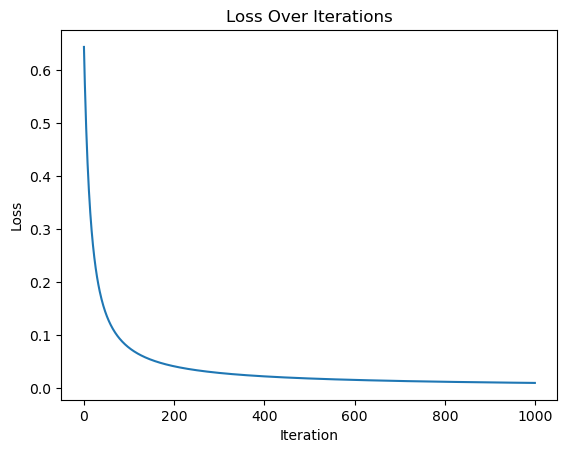

In [30]:
# Plot loss history
plt.plot(loss_history)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss Over Iterations')
plt.show()

#### Making Predictions

In [ ]:
# Predictions on test set
def predict(X, theta, threshold=0.5):
    probabilities = sigmoid(X @ theta)
    return (probabilities >= threshold).astype(int)

y_pred = predict(X_test, theta)

#### Evaluating The Model

In [32]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00         9

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



## Multi-Class Logistic Regression

While logistic regression is primarily associated with binary classification, it can be extended to handle problems involving more than two classes. This is achieved through strategies that adapt the binary logistic regression framework for multi-class scenarios. Two commonly used approaches are One-vs-Rest (OvR) and Multinomial Logistic Regression.

#### One-vs-Rest (OvR)

In the One-vs-Rest approach, separate binary logistic regression models are trained for each class. Each model predicts the probability of a sample belonging to one specific class versus all other classes combined. For a dataset with \(k\) classes, \(k\) binary models are built. During prediction, the class corresponding to the model with the highest probability is selected. OvR is computationally efficient and straightforward to implement, making it a popular choice for extending logistic regression to multi-class problems.

#### Multinomial Logistic Regression

Multinomial logistic regression directly models the probability distribution across all classes. Instead of treating each class separately, a single model is trained to estimate the probabilities of all possible classes simultaneously. These probabilities are calculated using the softmax function, which generalizes the logistic function for multi-class settings. The softmax function ensures that the predicted probabilities for all classes sum to 1, allowing the model to output a well-defined probability distribution.

Multinomial logistic regression is particularly suited for problems where class relationships are more complex, as it captures the interdependencies between classes more effectively than OvR.

![](https://miro.medium.com/v2/resize:fit:972/1*SwXHlCzh-d9UqHOglp3vcA.png)

### One vs. Rest Logistic Regression Example

#### Loading Data

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Iris dataset
iris = load_iris()
X = iris.data  # Features
y = iris.target  # Target labels

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Building The Model

In [ ]:
# Logistic regression for multi-class classification using One-vs-Rest
model = LogisticRegression(multi_class='ovr', solver='lbfgs', random_state=42, max_iter=500)
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

#### Evaluating The Model

In [ ]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("One-vs-Rest Logistic Regression Accuracy:", accuracy)

In [ ]:
# Detailed classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

In [ ]:
# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix for One-vs-Rest Logistic Regression")
plt.show()

### Multinomial Logistic Regression Example

#### Load The Data

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Iris dataset
iris = load_iris()
X = iris.data  # Features
y = iris.target  # Target labels

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Build The Model

In [ ]:
# Logistic regression for multi-class classification
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', random_state=42, max_iter=500)
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

#### Evaluate The Model

In [ ]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Multinomial Logistic Regression Accuracy:", accuracy)

In [ ]:
# Detailed classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

In [ ]:
# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix for Multinomial Logistic Regression")
plt.show()

### Multinomial Logistic Regression From Scratch

#### Load The Data

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt

# Load the Iris dataset
iris = load_iris()
X = iris.data  # Features
y = iris.target  # Target labels

# One-hot encode the target labels -- different from other steps as the by hand approach needs starting values.
encoder = OneHotEncoder(sparse=False)
y_onehot = encoder.fit_transform(y.reshape(-1, 1))

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

# Add a bias term to the features -- different from other steps as the by hand approach needs starting values.
X_train = np.c_[np.ones((X_train.shape[0], 1)), X_train]  # Add bias column
X_test = np.c_[np.ones((X_test.shape[0], 1)), X_test]  # Add bias column

#### Initializing Parameters

In [ ]:
# Initialize parameters
num_classes = y_train.shape[1]
num_features = X_train.shape[1]
theta = np.zeros((num_features, num_classes))  # Shape: (num_features, num_classes)
learning_rate = 0.1
num_iterations = 1000

#### Defining The Functions

In [ ]:
# Define the softmax function
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # Stability improvement
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# Define the cross-entropy loss function
def compute_loss(X, y, theta):
    m = X.shape[0]
    logits = X @ theta  # Linear scores
    probs = softmax(logits)  # Predicted probabilities
    loss = -np.sum(y * np.log(probs)) / m
    return loss

# Define the gradient function
def compute_gradient(X, y, theta):
    m = X.shape[0]
    logits = X @ theta
    probs = softmax(logits)
    gradient = (1 / m) * (X.T @ (probs - y))  # Shape: (num_features, num_classes)
    return gradient

#### Implementing Gradient Descent

In [ ]:
# Gradient descent
loss_history = []
for i in range(num_iterations):
    gradient = compute_gradient(X_train, y_train, theta)
    theta -= learning_rate * gradient  # Update parameters
    loss = compute_loss(X_train, y_train, theta)
    loss_history.append(loss)
    if i % 100 == 0:
        print(f"Iteration {i}: Loss = {loss:.4f}")

#### Plotting The Loss

In [ ]:
# Plot the loss history
plt.plot(loss_history)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss Over Iterations')
plt.show()

#### Making Predictions

In [ ]:
# Predictions
def predict(X, theta):
    logits = X @ theta
    probs = softmax(logits)
    return np.argmax(probs, axis=1)  # Return class with highest probability

y_pred = predict(X_test, theta)
y_test_labels = np.argmax(y_test, axis=1)  # Convert one-hot to class labels

#### Evaluating The Model

In [ ]:
# Evaluate the model
accuracy = np.mean(y_pred == y_test_labels)
print("Test Accuracy:", accuracy)

## Deeper Dive Into Key Concepts

### Minimizing the Sum of Squared Errors (SSE) - Linear Regression

#### What are Squared Errors?

In machine learning and statistics, **errors** (or residuals) refer to the difference between the **actual values** of the target variable and the **predicted values** produced by a model. When we perform regression tasks, the error for each data point is given by:

$$
\text{Error}_i = y_i - \hat{y}_i
$$

Where:
- $ y_i $ is the actual value (observed data),
- $ \hat{y}_i $ is the predicted value (from the model).

#### Squared Errors

**Squared error** is simply the square of this error:

$$
\text{Squared Error}_i = (y_i - \hat{y}_i)^2
$$

Squaring the error has two main effects:

1. **Emphasizing Larger Errors:** Squaring makes larger errors more significant because larger deviations from the actual values are penalized more heavily.

2. **Positive Values:** Squaring ensures that all errors are positive, avoiding issues of negative errors canceling out positive ones when summing across multiple data points.

For a dataset with multiple data points, the **sum of squared errors (SSE)** is calculated as:

$$
SSE = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

Where $ n $ is the number of data points.

#### Minimizing the Sum of Squared Errors (SSE)

The goal in **linear regression** is to find the model parameters (slope and intercept) that minimize the sum of squared errors. By minimizing SSE, we ensure that the predicted values are as close as possible to the actual values, on average.

Mathematically, in the context of simple linear regression, the prediction $ \hat{y}_i $ is modeled as:

$$
\hat{y}_i = \beta_0 + \beta_1 x_i
$$

Where:
- $ \beta_0 $ is the intercept,
- $ \beta_1 $ is the slope,
- $ x_i $ is the input (independent variable).

We want to find the values of $ \beta_0 $ and $ \beta_1 $ that minimize the sum of squared errors:

$$
\min_{\beta_0, \beta_1} \sum_{i=1}^{n} (y_i - (\beta_0 + \beta_1 x_i))^2
$$

This minimization problem is typically solved using calculus or numerical optimization methods (like **gradient descent**), leading to the least squares solution.

![](hk00xm44y2o91.gif)

### Gradient Descent 

In both linear and logistic regression, our goal is to find a set of parameters (also called weights or coefficients) that minimize a **cost function**. This cost function tells us how far off our model's predictions are from the actual outcomes.

However, for most cost functions used in machine learning, we can’t solve for the optimal weights directly using algebra. Instead, we use a method called **gradient descent** to find the best parameters iteratively.


#### What is Gradient Descent?

Gradient descent is an iterative optimization algorithm used to find model parameters that minimize a cost function. It works by computing the **gradient** (or slope) of the cost function with respect to the model’s parameters, and then **moving in the opposite direction** of that gradient. Why the opposite direction? Because we want to go **downhill** toward the minimum, not uphill. The intuition here is simple: repeatedly adjust the model parameters in the direction that most reduces the error.

At each iteration, for parameter $ \theta_j $, the update rule is:

$$
\theta_j := \theta_j - \alpha \frac{\partial J(\theta)}{\partial \theta_j}
$$

Where:
- $ \theta_j $ is the $j$th parameter (weight),
- $ \alpha $ is the **learning rate**, which controls how big of a step we take,
- $ \frac{\partial J}{\partial \theta_j} $ is the partial derivative of the cost function $J$ with respect to $ \theta_j $.

This update is repeated over and over until the algorithm converges (i.e., the cost function stops decreasing or the change is very small).

The **learning rate** ($\alpha$) controls the size of each step toward minimizing the cost function:
- If $\alpha$ is too large, the algorithm may overshoot the minimum and fail to converge.
- If $\alpha$ is too small, the convergence process becomes slow.

**Choosing the right learning rate is crucial for efficient training.**
 
Also, gradient descent can stop when a **stopping condition** is met:
- The change in the cost function between iterations is below a predefined threshold.
- A maximum number of iterations is reached.

#### Gradient Descent in Plain Language

1. **Pick a Starting Point**  
   Begin with some initial settings for your model. These are usually chosen at random or set to simple default values.

2. **See How You’re Doing**  
   Using your current settings, measure how far off your model’s predictions are from the actual results. This gives you a sense of whether you’re doing well or need to improve.

3. **Find Which Way to Move**  
   Determine which direction would improve your performance. You do this by checking whether a small tweak in each setting makes the performance better or worse.

4. **Make a Small Adjustment**  
   Once you know which way improves your model, you adjust each setting a little bit in that direction. The size of these tweaks is controlled so you don’t overdo it.

5. **Repeat Until Improvement Stops**  
   You keep measuring performance, finding the best direction, and making small adjustments over and over. Eventually, the improvements become very small and you stop the process.


### Gradient Descent in Linear Regression

In linear regression, we use the **mean squared error** as our cost function:

$$
J(\theta) = \frac{1}{2m} \sum_{i=1}^m (h_\theta(x^{(i)}) - y^{(i)})^2
$$

Where:
- $ h_\theta(x^{(i)}) = \theta_0 + \theta_1 x^{(i)} $ is our prediction,
- $ m $ is the number of training examples,
- $ y^{(i)} $ is the actual target value.

To minimize this cost, we take the partial derivatives:

$$
\frac{\partial J}{\partial \theta_0} = \frac{1}{m} \sum_{i=1}^m (h_\theta(x^{(i)}) - y^{(i)})
$$

$$
\frac{\partial J}{\partial \theta_1} = \frac{1}{m} \sum_{i=1}^m (h_\theta(x^{(i)}) - y^{(i)}) \cdot x^{(i)}
$$

Using these, the update rules become:

$$
\theta_0 := \theta_0 - \alpha \cdot \frac{1}{m} \sum_{i=1}^m (h_\theta(x^{(i)}) - y^{(i)})
$$

$$
\theta_1 := \theta_1 - \alpha \cdot \frac{1}{m} \sum_{i=1}^m (h_\theta(x^{(i)}) - y^{(i)}) \cdot x^{(i)}
$$

This process is repeated for many iterations, slowly improving the model’s fit to the data.

Once training is complete, we can interpret the results of the model. Here, with linear regression, $\theta_1$ indicates the strength and direction of the relationship and $\theta_0$ gives the baseline prediction when all features are zero.  


### Gradient Descent in Logistic Regression

Logistic regression has a different cost function because it's designed for **classification** rather than regression. Instead of predicting continuous outputs, it predicts **probabilities** between 0 and 1.

The prediction function (hypothesis) uses the **sigmoid function**:

$$
h_\theta(x) = \frac{1}{1 + e^{-\theta^T x}}
$$

And the cost function is:

$$
J(\theta) = -\frac{1}{m} \sum_{i=1}^m \left[ y^{(i)} \log(h_\theta(x^{(i)})) + (1 - y^{(i)}) \log(1 - h_\theta(x^{(i)})) \right]
$$

Where:
- $ h_\theta(x) = \frac{1}{1 + e^{-\theta^T x}} $: Sigmoid hypothesis
- $ m $: Number of training examples  
- $ \theta $: Model parameters  
- $ x^{(i)} $: Input features  
- $ y^{(i)} $: True label (0 or 1)

This is called **log loss** or **binary cross-entropy**. It punishes the model more harshly for making confident but wrong predictions.

The gradient of the logistic regression cost function is:

$$
\frac{\partial J}{\partial \theta} = \frac{1}{m} X^T (h_\theta(X) - y)
$$

Where:
- $ X $ is the matrix of input features,
- $ y $ is the vector of true labels,
- $ h_\theta(X) $ is the vector of predicted probabilities (sigmoid outputs).

The update rule for logistic regression is then:

$$
\theta := \theta - \alpha \cdot \frac{1}{m} X^T (h_\theta(X) - y)
$$

Where:
- $\alpha$: Learning rate, controlling the step size.
- $\frac{1}{m} X^T (h_\theta(X) - y)$: Gradient of the cost function.

Just like with linear regression, we repeat this update until convergence.

### Stochastic Gradient Descent (SGD)

**Stochastic Gradient Descent** is an optimization algorithm used to minimize a cost function by updating model parameters using the gradient of the loss with respect to the parameters.

Unlike traditional **Gradient Descent**, which computes the gradient using the entire training dataset, **SGD** updates the parameters using **just one training example at a time**. A compromise between these two is **Mini-batch Gradient Descent**, which uses a small subset (mini-batches) of the data.

#### Benefits of SGD:
- **Faster updates**: The model begins learning immediately after seeing the first few examples.
- **Lower memory requirements**: Only one (or a few) examples are needed in memory per update.
- **Escaping local minima**: The inherent noise in the updates can help the model escape shallow local minima or saddle points, potentially improving generalization.


### Linear Regression with SGD

For linear regression, the hypothesis is:

$$
h_\theta(x^{(i)}) = \theta_0 + \theta_1 x^{(i)}
$$

Given a training example $(x^{(i)}, y^{(i)})$, the cost is the squared error:

$$
J(\theta) = \frac{1}{2}(h_\theta(x^{(i)}) - y^{(i)})^2
$$

The gradients with respect to $\theta_0$ and $\theta_1$ are used to update the parameters:

$$
\theta_0 := \theta_0 - \alpha \cdot (h_\theta(x^{(i)}) - y^{(i)})
$$

$$
\theta_1 := \theta_1 - \alpha \cdot (h_\theta(x^{(i)}) - y^{(i)}) \cdot x^{(i)}
$$

These updates are repeated for many iterations, with each step nudging the parameters to reduce the prediction error.


### Logistic Regression with SGD

For logistic regression, the hypothesis uses the sigmoid function:

$$
h_\theta(x^{(i)}) = \frac{1}{1 + e^{-\theta^T x^{(i)}}}
$$

Given a training example $(x^{(i)}, y^{(i)})$, the update rule becomes:

$$
\theta := \theta - \alpha \cdot (h_\theta(x^{(i)}) - y^{(i)}) \cdot x^{(i)}
$$

This rule is derived from the gradient of the **log loss** (cross-entropy) cost function.

Each update helps adjust the parameters $\theta$ to increase the model’s confidence in correctly classifying the input. Over many updates and epochs, the model gradually learns a decision boundary that separates the classes.

### Regularization

**Regularization** is a technique used to prevent overfitting by discouraging complex models in logistic regression and other machine learning algorithms. It works by adding a penalty term to the cost function, which limits the magnitude of the model's parameters (weights). This helps ensure the model generalizes well to unseen data, especially in situations where there are many features or limited training samples.

#### Types of Regularization

1. **L1 Regularization (Lasso)**:
   - Adds a penalty proportional to the absolute value of the coefficients.
   - Encourages sparsity, often driving some coefficients to zero, which can be useful for feature selection.
   - Penalty term: $$\lambda \sum |\theta_j|$$


2. **L2 Regularization (Ridge)**:
   - Adds a penalty proportional to the square of the coefficients.
   - Encourages small weights without forcing them to be exactly zero, making it suitable when all features are potentially useful.
   - Penalty term: $$\lambda \sum \theta_j^2$$

3. **Elastic Net**:
   - Combines both L1 and L2 penalties.
   
#### Regularized Linear Regression Cost Function (L2):

$$
J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)})^2 + \frac{\lambda}{2m} \sum_{j=1}^{n} \theta_j^2
$$

#### Regularized Logistic Regression Cost Function (L2):

$$
J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} \left[y^{(i)} \log(h_\theta(x^{(i)})) + (1 - y^{(i)}) \log(1 - h_\theta(x^{(i)}))\right] + \frac{\lambda}{2m} \sum_{j=1}^{n} \theta_j^2
$$

The regularization term excludes $ \theta_0 $ in most implementations.


### The Sigmoid Function (Binary Logistic Regression)

The **sigmoid function** is used in binary logistic regression to map any real-valued input to the range $(0, 1)$, making it suitable for modeling probabilities.

Given an input $z = \theta^T x$, the sigmoid function is defined as:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

This output can be interpreted as the probability that the input $x$ belongs to the positive class (class 1):

- If $\sigma(z) \approx 1$, the model predicts **class 1** with high confidence.
- If $\sigma(z) \approx 0$, the model predicts **class 0** with high confidence.

In binary classification, the predicted class is usually determined by thresholding the output at 0.5:

$$
\text{Predicted class} =
\begin{cases}
1 & \text{if } \sigma(z) \geq 0.5 \\
0 & \text{otherwise}
\end{cases}
$$

During training, the model uses the **binary cross-entropy loss** to measure the difference between the predicted probability and the true label.

### The Softmax Function (Multi-Class Logistic Regression)

The **softmax function** generalizes the sigmoid to multi-class classification by converting a vector of real-valued scores (logits) into a probability distribution over $k$ classes.

Given logits $z = [z_1, z_2, \dots, z_k]$, the softmax function outputs probabilities $p = [p_1, p_2, \dots, p_k]$ where:

$$
p_i = \frac{e^{z_i}}{\sum_{j=1}^{k} e^{z_j}}
$$

This transformation ensures:
1. $p_i \geq 0$ for all $i$ (non-negative outputs)
2. $\sum_{i=1}^{k} p_i = 1$ (probabilities sum to 1)

Each $p_i$ represents the model’s estimated probability that the input belongs to class $i$.

#### Role in Multi-Class Logistic Regression

In **multi-class logistic regression**, each class $i$ has an associated linear score (logit):

$$
z_i = w_i^T x + b_i
$$

Where:
- $x$: Input feature vector  
- $w_i$: Weight vector for class $i$  
- $b_i$: Bias term for class $i$

The softmax function is applied to the logits $z_1, \dots, z_k$ to produce class probabilities. The model predicts the class with the highest probability:

$$
\text{Predicted class} = \arg\max_i(p_i)
$$

## Real World Example

### Linear Regression

#### Import necessary libraries

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt

#### Load The Dataset

In [ ]:
path = 'Kaggle_Housing_Data.csv'
df = pd.read_csv(path)

In [ ]:
df.head()

#### Check Correlations

In [ ]:
correlation = df['area'].corr(df['stories'])

print(f"Correlation between Variable1 and Variable2: {correlation:.4f}")

#### Use A Correlation Matrix

In [ ]:
# Compute the correlation matrix
correlation_matrix = df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(8, 6))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)

# Add title to the heatmap
plt.title('Correlation Matrix Heatmap', fontsize=15)

# Show the plot
plt.show()

#### Prepare The Data

In [ ]:
# Check the columns in the dataset
print(df.columns)

In [ ]:
# Convert categorical columns to numerical values (if needed)
# For example: 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', and 'furnishingstatus'
df['mainroad'] = df['mainroad'].map({'yes': 1, 'no': 0})
df['guestroom'] = df['guestroom'].map({'yes': 1, 'no': 0})
df['basement'] = df['basement'].map({'yes': 1, 'no': 0})
df['hotwaterheating'] = df['hotwaterheating'].map({'yes': 1, 'no': 0})
df['airconditioning'] = df['airconditioning'].map({'yes': 1, 'no': 0})
df['prefarea'] = df['prefarea'].map({'yes': 1, 'no': 0})
df['furnishingstatus'] = df['furnishingstatus'].map({'furnished': 2, 'semi-furnished': 1, 'unfurnished': 0})

#### Set Up Your X and y Datasets

In [ ]:
# Features (X) and Target (y)
X = df[['area', 'bedrooms', 'bathrooms','stories', 'mainroad', 'guestroom','basement', 'hotwaterheating', 
        'airconditioning', 'parking', 'prefarea', 'furnishingstatus']]

y = df['price']

In [ ]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Initialize The Model And Make Predictions

In [ ]:
# Initialize and Train the Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Make Predictions
y_pred = model.predict(X_test)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

#### Calculate Model Performance

In [ ]:
# Calculate Model Performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

#### Example Prediction With New Input

In [ ]:
# Example new house data: area=3000, 3 bedrooms, 2 bathrooms, 2 stories, mainroad=yes, guestroom=no, etc.

new_house = [[3000, 3, 2, 2, 1, 0, 1, 0, 1, 2, 1, 2]]
predicted_price = model.predict(new_house)
print(f"Predicted Price for new house: ${predicted_price[0]:,.2f}")